In [1]:
#Import Libraries

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Build Encoder-Decoder

def build_inpainting_autoencoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)

    # Bottleneck
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)

    # Decoder
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mae')
    return model


model = build_inpainting_autoencoder()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 32)        │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 128, 128, 3)         │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 186,371 (728.01 KB)

 Trainable params: 186,371 (728.01 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
#Create Masking Function

def apply_random_mask_np(img, mask_size=20):
    img = img.copy()
    h, w, _ = img.shape
    y = np.random.randint(0, h - mask_size)
    x = np.random.randint(0, w - mask_size)

    img[y:y+mask_size, x:x+mask_size] = 0
    return img.astype(np.float32)


def apply_random_mask(img):
    return tf.numpy_function(apply_random_mask_np, [img], tf.float32)

In [4]:
#Load and Pre-process Dataset

(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalise
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Resize images (TensorFlow → NumPy)
x_train = tf.image.resize(x_train, (128, 128))
x_test  = tf.image.resize(x_test,  (128, 128))

masked_train = np.array([apply_random_mask(img).numpy() for img in x_train])
masked_test  = np.array([apply_random_mask(img).numpy() for img in x_test])

In [5]:
#Train Model

history = model.fit(
    masked_train, x_train,
    validation_data=(masked_test, x_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 851s 1s/step - loss: 0.0255 - val_loss: 0.0105
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 819s 1s/step - loss: 0.0116 - val_loss: 0.0098
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 809s 1s/step - loss: 0.0097 - val_loss: 0.0075
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 816s 1s/step - loss: 0.0087 - val_loss: 0.0064
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 830s 1s/step - loss: 0.0083 - val_loss: 0.0068
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 809s 1s/step - loss: 0.0080 - val_loss: 0.0083
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 824s 1s/step - loss: 0.0072 - val_loss: 0.0093
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 811s 1s/step - loss: 0.0075 - val_loss: 0.0083
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 820s 1s/step - loss: 0.0065 - val_loss: 0.0063
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 815s 1s/step - loss: 0.0071 - val_loss: 0.0058


In [6]:
#Use Model

def show_inpainting(original, masked):
    pred = model.predict(masked[None])[0]

    plt.figure(figsize=(8,3))
    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Masked")
    plt.imshow(masked)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Inpainted")
    plt.imshow(pred)
    plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


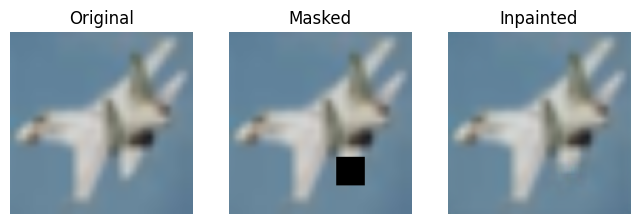

In [9]:
img = x_test[10].numpy()
masked = apply_random_mask(img).numpy()

show_inpainting(img, masked)